In [12]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, estimate_EEI_avg, get_window_avg_maps, check_EEI_consistency, get_all_jd_windows, get_acc_to_flux_factor #, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms, noise_asd_grattis
from SpaceBalls.sph_meshing import Grid, RegularLatLonGrid, QuadratureGrid
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.plotter import Plotter
import config.constants as constants
RE = constants.earth_radius()
import itertools
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
%matplotlib inline

def get_EEI_smooth_true(EEI_name, window_days):

    #EEI_name = "EEI_truth_0"
    rad_settings = radiation_settings_from_EEI_truth_name(EEI_name)
    full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(rad_settings["jd_interval"]))
    mid_day_jd_array = get_mid_day_jd_array(EEI_name)
    EEI_true_time_series = get_true_EEI_time_series(EEI_name)

    EEI_smooth_true = normal_smoother(EEI_true_time_series, full_jd_array, window_width_days=window_days, 
                                    out_length_mode='same_with_nans')
    EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)

    return EEI_smooth_true_coarse

def compute_EEI_estimated_time_series(SB_constellation, window_days, grid: Grid, frame, method, EEI_name=None, 
                                      accelerometer_dict=None, meas_mode='recomp_radial'):

    if EEI_name is None:
        EEI_name = check_EEI_consistency(SB_constellation)
    
    orbits_str = '|'.join([input_manager.get_dicts(sb)['orbit']['orbit_name'] for sb in SB_constellation])
    print(f"Running EEI estimatie for constellation {orbits_str}...")

    #for window_name, window_days in zip(smoothing_windows_names, smoothing_windows_days):
    print(f"Running smooth estimate {window_days}-day window")
    #rad_config = radiation_settings_from_EEI_truth_name(EEI_name)
    jd_windows = get_all_jd_windows(EEI_name, window_days)

    EEI_smooth_estimated = estimate_EEI_avg(
                                    sb_names=SB_constellation, 
                                    jd_windows=jd_windows, 
                                    grid=grid, method=method, frame=frame,
                                    meas_mode=meas_mode,
                                    return_avg_flux_maps=False,
                                    accelerometer_dict=accelerometer_dict
                                    )
    return EEI_smooth_estimated


def plot_estimation(estimations_dict, jd_array, constellation_name, add_zero_line=False):

    Plotter.plot_time_series(jd_array,
                    estimations_dict,
                    f_width=2.5, f_height=0.5,
                    ylabel='Net TOA flux (W/m$^2$)',
                    title=constellation_name,
                    zero_hline=add_zero_line
                    )

f_vec_grattis_paper = np.logspace(-4, 0, 300)
asd_grattis_paper = noise_asd_grattis(f_vec_grattis_paper)

Running EEI estimatie for constellation G3|A1|F12...
Running smooth estimate 365-day window
Computing batch 0
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output variable: jd_vec
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output variable: jd_vec
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output variable: jd_vec
Getting r_hist_array...
Getting output variable: xyz_sun_frame
Entering get_global_meas_idxs for var xyz_sun_frame
Getting output variable: jd_vec
Getting output variable: xyz_sun_frame
Entering get_global_meas_idxs for var xyz_sun_frame
Getting output variable: jd_vec
Getting output variable: xyz_sun_frame
Entering get_global_meas_idxs for var xyz_sun_frame
Getting output variable: jd_vec
Getting output variable: srp_recomp_radial
Entering get_global_meas_idxs for var srp_recomp_radial
Getting output variable: jd_vec
Getting output variable: srp_recomp_rad

/home/llbu9955/Space-Balls-MST/sbfinal-master/src/SpaceBalls/utils.py:751: RuntimeWarning: divide by zero encountered in power
  actuation = 2*np.sqrt(2)*10**(-12.5) * f_vec_abs**(-0.5)


Computing sparse arrays for sc 0
Shape all_radial_measurement_arrays[sc_i]: (10517760,)
Shape r_hist_array[sc_i]: (10517760, 3)
Computing sparse arrays for sc 1
Shape all_radial_measurement_arrays[sc_i]: (10517760,)
Shape r_hist_array[sc_i]: (10517760, 3)
Computing sparse arrays for sc 2
Shape all_radial_measurement_arrays[sc_i]: (10517760,)
Shape r_hist_array[sc_i]: (10517760, 3)
[array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])]
Running EEI estimatie for constellation G3|A1|F12...
Running smooth estimate 365-day window
Computing batch 0
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output variable: jd_vec
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output variable: jd_vec
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output 

/tmp/ipykernel_1307786/3005578980.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


Text(0, 0.5, 'Extra error acc. (W/m$^2$)')

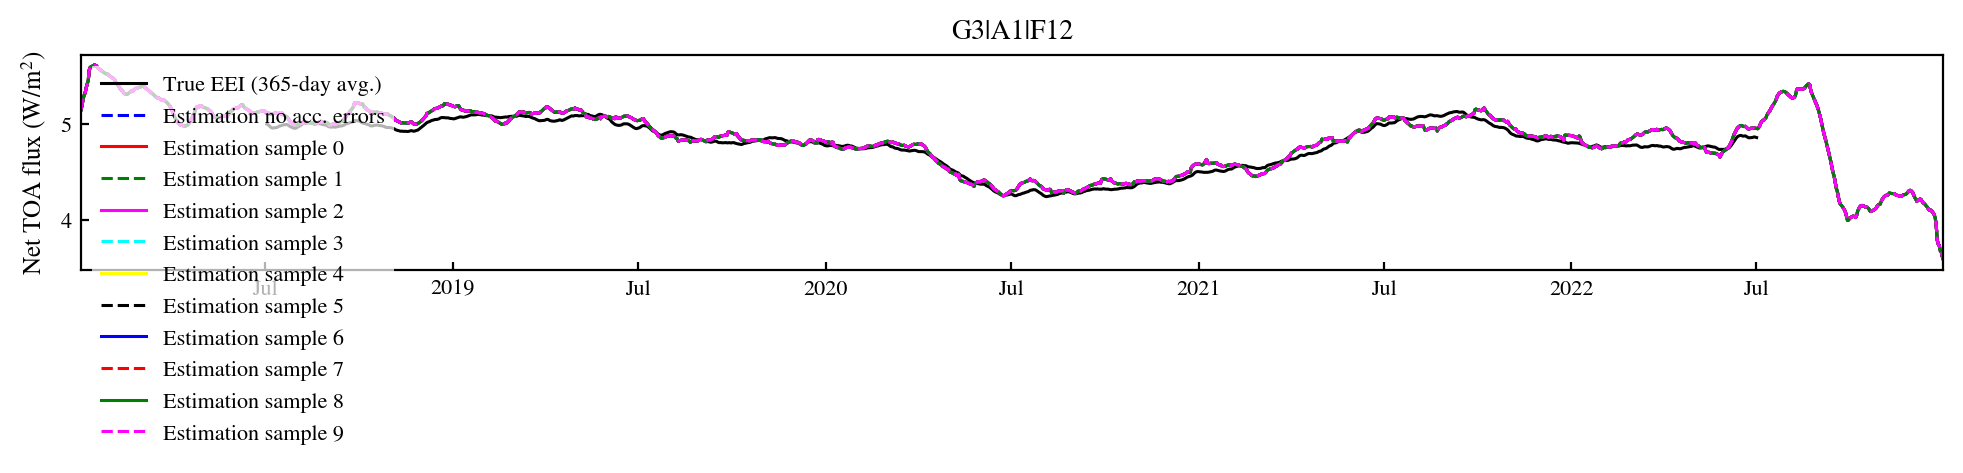

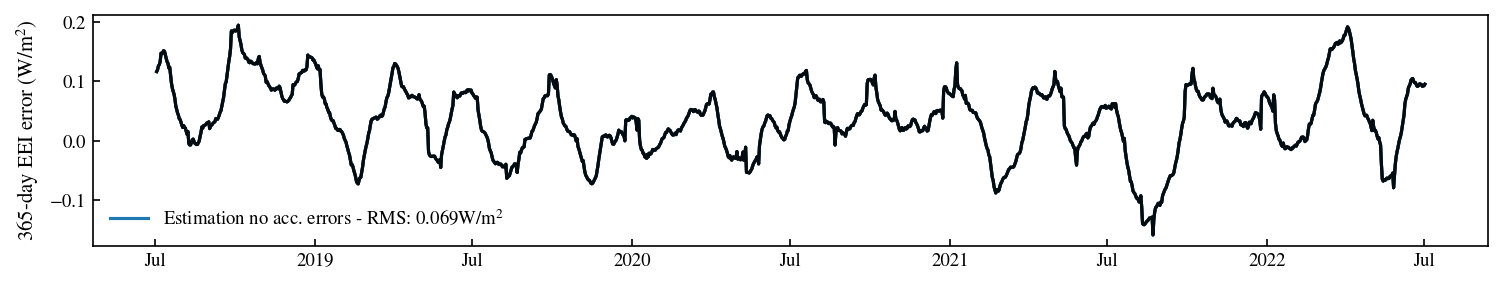

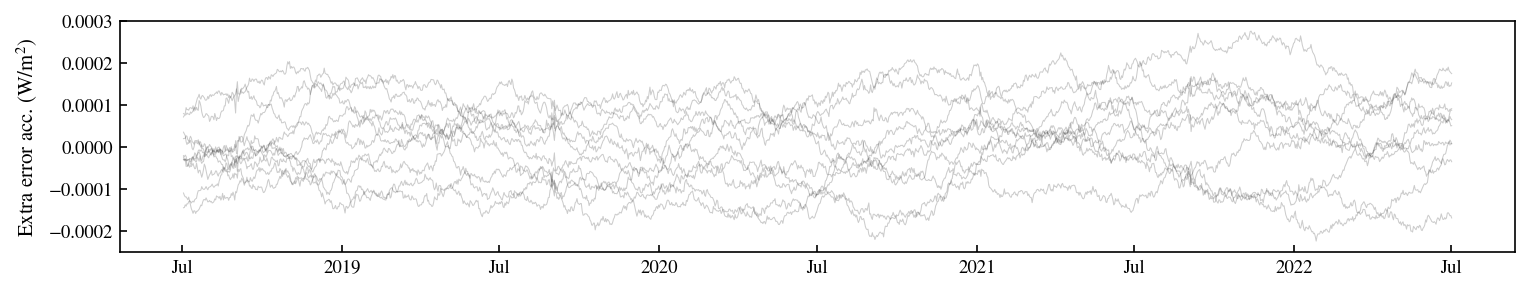

In [18]:
# single run

#orbits = ['I3', 'A1', 'F2'] # best 1-yr window
orbits = ['G3', 'A1', 'F12'] # 2nd best 1-yr window
#orbits = ['E3', 'E1', 'C2'] # best 1-month window
#orbits = ['E1', 'I2'] # best 1-yr 2 sats
#orbits = ['E1', 'E3'] # best 1-mo 2 sats
EEI_name = "EEI_truth_1" # check_EEI_consistency(SB_constellation)
window_days = 365
stacking_grid = QuadratureGrid(alt_km=800, order=131)
frame='SFF'
method='binary_gridding'
revs_per_T = 100


EEI_truth_smooth = get_EEI_smooth_true(EEI_name, window_days)
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
SB_constellation = np.concatenate([input_manager.get_primary_keys({'orbit_name': orb,
                                                        'force_settings': 2,
                                                        'integration_settings': 0,
                                                        'delta_t_out': 15,
                                                        'sc_name': 'SC_0',
                                                        }) for orb in orbits])
n_sb = len(SB_constellation)
orbits_str = '|'.join([input_manager.get_dicts(sb)['orbit']['orbit_name'] for sb in SB_constellation])
estimated_EEI_no_noise = compute_EEI_estimated_time_series(SB_constellation, window_days, stacking_grid, frame, 
                                                  method, EEI_name, {})

dict_to_plot = {'True EEI ('+str(window_days)+'-day avg.)': EEI_truth_smooth,
                'Estimation no acc. errors': estimated_EEI_no_noise
                }


n_samples = 10
rms_array = np.zeros(n_samples)
bias_array = np.zeros(n_samples)
std_array = np.zeros(n_samples)

for i in range(n_samples):

    scale_matrices_wrt_eye = [np.array([[0, 0, 0], 
                                        [0, 0, 0], 
                                        [0, 0, 0]]) for _ in range(n_sb)]

    e_1_sigma = 0
    cross_talk_1_sigma = 0
    misalign_1_sigma = 0

    scale_matrices_wrt_eye = [None] * n_sb
    for j in range(n_sb):
        e_a = 0 #np.random.randn(1)[0]*e_1_sigma
        e_b = 0 #np.random.randn(1)[0]*e_1_sigma
        e_c = 0 #np.random.randn(1)[0]*e_1_sigma
        alpha = np.random.randn(1)[0] * cross_talk_1_sigma
        beta = np.random.randn(1)[0] * cross_talk_1_sigma
        gamma = np.random.randn(1)[0] * cross_talk_1_sigma
        zeta = np.random.randn(1)[0] * misalign_1_sigma
        epsilon = np.random.randn(1)[0] * misalign_1_sigma
        delta = np.random.randn(1)[0] * misalign_1_sigma

        scale_matrices_wrt_eye[j] = np.array([[e_a, alpha + zeta, beta - epsilon],
                                              [alpha - zeta, e_b, gamma + delta],
                                              [beta + epsilon, gamma - delta, e_c]])

    scale_matrices = [np.eye(3) + delta_S for delta_S in scale_matrices_wrt_eye]

    accelerometer_dict = {  'noise_asd': 'grattis', # 5e-9
                            'biases': np.array([[0, 0, 0] for _ in range(n_sb)]), # rows: sats; cols: RIC
                            'scale_matrices': scale_matrices,
                            'subsample_dt': None,
                            'rotation_revs_per_T': np.ones(n_sb) * revs_per_T,
                            'rotation_axes_RIC': np.array([[0,1,1] for _ in range(n_sb)])
                        }
    
    print(accelerometer_dict['scale_matrices'])
    scale_mats = np.array(accelerometer_dict['scale_matrices'])
    #mean_scale = np.mean(scale_mats[np.nonzero(scale_matrices_wrt_eye)])
    #print(f"Mean scale: {mean_scale}")

    estimated_EEI = compute_EEI_estimated_time_series(SB_constellation, window_days, stacking_grid, frame, 
                                                    method, EEI_name, accelerometer_dict)
    dict_to_plot['Estimation sample '+str(i)] = estimated_EEI
    
    error_time_series = estimated_EEI - EEI_truth_smooth
    rms_array[i] = nanrms(error_time_series)
    bias_array[i] = np.nanmean(error_time_series)
    std_array[i] = np.sqrt(np.nanmean((error_time_series - bias_array[i])**2))


plot_estimation(dict_to_plot, mid_day_jd_array, orbits_str)


#error_title = orbits_str + ' - error RMS: ' + f"{rms:.5f} W/m$^2$"
errors_dict = {}
for i, (label, estimated) in enumerate(dict_to_plot.items()):
    if i>0:#(len(dict_to_plot.items()))-1:
        error = estimated - EEI_truth_smooth
        rms = nanrms(error)
        errors_dict[label + ' - RMS: ' + f"{rms:.3f}" + 'W/m$^2$'] = error

fig, ax = plt.subplots(figsize=(12,2))
for i, (key, val) in enumerate((errors_dict.items())):
    if i==0:
        ax.plot(Plotter.jd_to_datetime(mid_day_jd_array), val, label=key)
    else:
        ax.plot(Plotter.jd_to_datetime(mid_day_jd_array), val, alpha=0.2, color='k')
    Plotter.format_time_labels(ax)

ax.legend()
ax.set_ylabel(str(window_days)+'-day EEI error (W/m$^2$)')

fig2, ax2 = plt.subplots(figsize=(12,2))
for i, (key, val) in enumerate((errors_dict.items())):
    if i>0:
        ax2.plot(Plotter.jd_to_datetime(mid_day_jd_array), val - list(errors_dict.values())[0], 
                 alpha=0.2, lw=0.5, color='k')
    Plotter.format_time_labels(ax2)

ax2.legend()
ax2.set_ylabel('Extra error acc. (W/m$^2$)')

#plot_estimation(errors_dict, mid_day_jd_array, orbits_str, add_zero_line=True)

In [ ]:
(get_acc_to_flux_factor(SB_constellation[0]) * 5e-9)

Getting output variable: srp
Getting output variable: srp
Getting output variable: srp
Getting output variable: erp
Getting output variable: erp
Getting output variable: erp
Getting output variable: aero
Getting output variable: aero
Getting output variable: aero
Getting output variable: jd_vec
Getting output variable: jd_vec
Getting output variable: jd_vec
Revs per T: 100; fw=0.01652232514572161
Revs per T: 100; fw=0.01652232514572161
Revs per T: 100; fw=0.01652232514572161


(1e-12, np.float64(0.0009010796434199793))

/tmp/ipykernel_361103/2334279406.py:67: RuntimeWarning: divide by zero encountered in divide
  ax_top_1 = ax_psd.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))


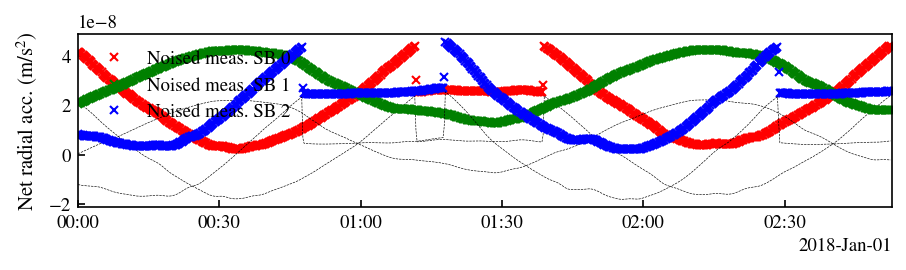

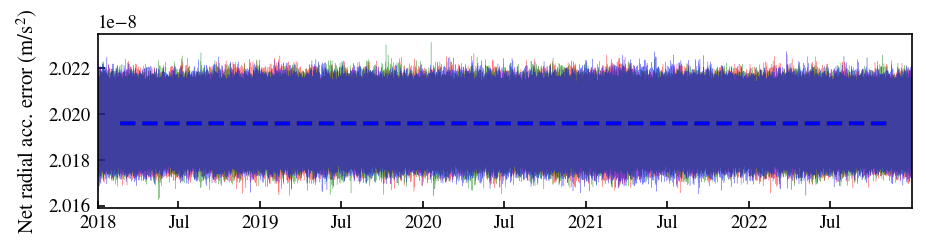

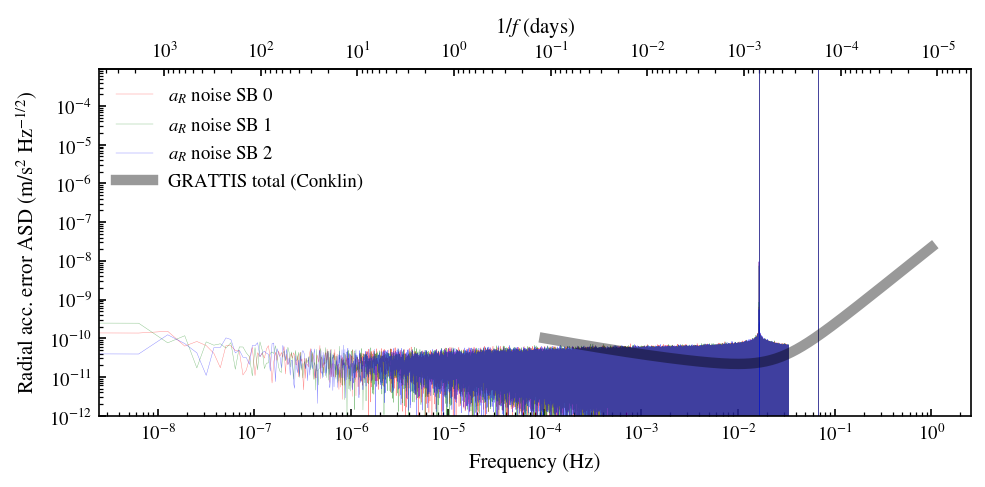

In [8]:
from SpaceBalls.postproc_EEI_estimation import get_radial_measurements_array, get_full_output_var_hist, get_orbital_periods
from SpaceBalls.utils import noise_asd_grattis, fft_to_power
import scipy.fft

cols = ['r', 'g', 'b']

n_days = 0.12
SB_constellation = [input_manager.get_primary_keys({'orbit_name': orbit,
                                                'force_settings': 2,
                                                'integration_settings': 0,
                                                'delta_t_out': 15,
                                                'sc_name': 'SC_0',
                                                })[0] for orbit in orbits]

acc_meas_radial = get_radial_measurements_array(SB_constellation, meas="acceleration")
jd_vecs =  get_full_output_var_hist(SB_constellation, 'jd_vec')
periods_min = get_orbital_periods(SB_constellation) # min

fig, ax = plt.subplots(figsize=(7,1.5))
fig_long, ax_long = plt.subplots(figsize=(7,1.5))
fig_psd, ax_psd = plt.subplots(figsize=(7.5,3))
f_vec_grattis_paper = np.logspace(-4, 0, 300)
asd_grattis_paper = noise_asd_grattis(f_vec_grattis_paper)

for i, sb in enumerate(SB_constellation):
    step_days = np.mean(np.diff(jd_vecs[i]))
    dt = step_days*24*3600
    fs = 1/(dt)
    max_idx = int(np.round(n_days / step_days))
    errors_time_series_RIC = np.load(os.path.join(OUTPUT_DIR, sb, 'error_time_series.npy'))
    jd_vec_saved_errors = np.load(os.path.join(OUTPUT_DIR, sb, 'jd_error_time_series.npy'))
    errors_radial = errors_time_series_RIC[:,0]
    og_radial_meas = acc_meas_radial[i]
    
    ax.plot(Plotter.jd_to_datetime(jd_vecs[i][:max_idx]), og_radial_meas[:max_idx] + errors_radial[:max_idx], 
            'x', label=f"Noised meas. SB {i}", color=cols[i])
    ax.plot(Plotter.jd_to_datetime(jd_vecs[i][:max_idx]), og_radial_meas[:max_idx], 
            color='k', linestyle='--', lw=0.3)
    
    ax_long.plot(Plotter.jd_to_datetime(jd_vec_saved_errors), errors_radial, label=f"Noise SB {i}", 
                 color=cols[i], lw=0.2, alpha=0.5)
    noise_smooth = normal_smoother(errors_radial, jd_vec_saved_errors, 100, 'same_with_nans')
    ax_long.plot(Plotter.jd_to_datetime(jd_vec_saved_errors), noise_smooth, linestyle='--',
                 color=cols[i], lw=2, zorder=10+i)
    
    X_noise = scipy.fft.rfft(errors_radial)                          # [m/s^2]
    freqs_noise = scipy.fft.rfftfreq(len(errors_radial), dt)   
    _, asd_noise = fft_to_power(X_noise, len(errors_radial), dt)
    ax_psd.loglog(freqs_noise, asd_noise, lw=0.2, alpha=0.5, color=cols[i], label=f"$a_R$ noise SB {i}")
    ax_psd.axvline(fs, lw=0.3, alpha=0.75, color=cols[i])
    f_w = 1/(periods_min[i]*60) * revs_per_T
    print(f"Revs per T: {revs_per_T}; fw={f_w}")
    ax_psd.axvline(f_w, lw=0.3, alpha=0.75, color=cols[i])
    
ax.set_xlim([Plotter.jd_to_datetime(jd_vecs[0][0]), Plotter.jd_to_datetime(jd_vecs[0][max_idx])])
ax.set_ylabel('Net radial acc. (m/s$^2$)')
Plotter.format_time_labels(ax)
ax.legend()

ax_long.set_xlim([Plotter.jd_to_datetime(jd_vecs[0][0]), Plotter.jd_to_datetime(jd_vecs[0][-1])])
ax_long.set_ylabel('Net radial acc. error (m/s$^2$)')
Plotter.format_time_labels(ax_long)

ax_psd.loglog(f_vec_grattis_paper, asd_grattis_paper, label='GRATTIS total (Conklin)', lw=5, color='k', alpha=0.4)
ax_psd.set_xlabel('Frequency (Hz)')
ax_psd.set_ylabel('Radial acc. error ASD (m/s$^2$ Hz$^{-1/2}$)')
ax_top_1 = ax_psd.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))
ax_top_1.set_xlabel('1/$f$ (days)')
ax_psd.legend()
ax_psd.set_ylim(bottom=1e-12)

In [7]:
from SpaceBalls.postproc_EEI_estimation import get_radial_measurements_array, get_full_output_var_hist, get_orbital_periods
from SpaceBalls.utils import noise_asd_grattis, fft_to_power
import scipy.fft

# copy to just plot the result from the overnight script
cols = ['r', 'g', 'b']

orbits = ['G3', 'A1', 'F12'] 
EEI_name = "EEI_truth_0" # check_EEI_consistency(SB_constellation)
window_days = 365
revs_per_T = 100

SB_constellation = np.concatenate([input_manager.get_primary_keys({'orbit_name': orb,
                                                    'force_settings': 2,
                                                    'integration_settings': 0,
                                                    'delta_t_out': 0.5,
                                                    }) for orb in orbits])
print(SB_constellation)
jd_windows = get_all_jd_windows(EEI_name, window_days)
n_batches = 5
jd_windows = np.array_split(jd_windows, n_batches)[-1] # only last batch is saved

acc_meas_radial = get_radial_measurements_array(SB_constellation, meas="acceleration", 
                                                meas_mode='recomp_radial', jd_windows=jd_windows) # high f
jd_vecs =  get_full_output_var_hist(SB_constellation, 'jd_vec', jd_windows=jd_windows) # high f
jd_vecs_ds =  get_full_output_var_hist(SB_constellation, 'jd_vec', jd_windows=jd_windows, downsample_dt=1.5) # low f
periods_min = get_orbital_periods(SB_constellation) # min




['3a5f604af534538d' 'f80b79a36a0fddc3' 'd6064ae0fdb103b2']
Getting output variable: srp_recomp_radial
Entering get_global_meas_idxs for var srp_recomp_radial
Getting output variable: jd_vec
Getting output variable: srp_recomp_radial
Entering get_global_meas_idxs for var srp_recomp_radial
Getting output variable: jd_vec
Getting output variable: srp_recomp_radial
Entering get_global_meas_idxs for var srp_recomp_radial
Getting output variable: jd_vec


IndexError: boolean index did not match indexed array along axis 0; size of axis is 315490802 but size of corresponding boolean axis is 315479846

In [ ]:
fig_raw, ax_raw = plt.subplots(figsize=(8,2.5))
fig_rawf, ax_rawf = plt.subplots(figsize=(8,2.5))
fig_noise, ax_noise = plt.subplots(figsize=(8,2.5))
fig_noise, ax_noisef = plt.subplots(figsize=(8,2.5))
fig_psd, ax_psd = plt.subplots(figsize=(6,4.5))
fig_psdf, ax_psdf = plt.subplots(figsize=(6,4.5))
f_vec_grattis_paper = np.logspace(-4, 0, 300)

def get_asd(errors, dt):
    X_noise = scipy.fft.rfft(errors)                          # [m/s^2]
    freqs_noise = scipy.fft.rfftfreq(len(errors), dt)   
    _, asd_noise = fft_to_power(X_noise, len(errors), dt)

    return freqs_noise, asd_noise

n_days = 0.02
SB_constellation = np.concatenate([input_manager.get_primary_keys({'orbit_name': orb,
                                                    'force_settings': 2,
                                                    'integration_settings': 0,
                                                    'delta_t_out': 0.5,
                                                    }) for orb in orbits])

plot_raw = False
plot_filtered = True

for i, sb in enumerate(SB_constellation):
    
    # HIGH FREQ plots
    step_days = np.mean(np.diff(jd_vecs[i])) # high f
    dt = step_days*24*3600
    fs = 1/(dt)
    print(f"fs={fs}")
    dt_ds = np.mean(np.diff(jd_vecs_ds[i]))*24*3600
    max_idx_h = int(np.round(n_days / step_days))

    # high f meas plot
    og_radial_meas = acc_meas_radial[i] # high f
    if plot_raw:
        ax_raw.plot(Plotter.jd_to_datetime(jd_vecs[i][:max_idx_h]), og_radial_meas[:max_idx_h], 
            color='k', linestyle='--', lw=0.3)
        raw_acc_meas_with_errors = np.load(os.path.join(OUTPUT_DIR, sb, 'raw_acc_meas_with_errors.npy'))
        ax_raw.plot(Plotter.jd_to_datetime(jd_vecs[i][:max_idx_h]), raw_acc_meas_with_errors[:max_idx_h,0],
                    'x', label=f"Noised meas. SB {i}", color=cols[i])
        
        errors_high_f = raw_acc_meas_with_errors[:,0] - og_radial_meas
        ax_noise.plot(Plotter.jd_to_datetime(jd_vecs[i]), errors_high_f, color=cols[i], lw=0.2, 
                  alpha=0.5)

    # filtered high f meas plot
    if plot_filtered:
        ax_rawf.plot(Plotter.jd_to_datetime(jd_vecs[i][:max_idx_h]), og_radial_meas[:max_idx_h], 
            color='k', linestyle='--', lw=0.3)
        smooth_acc_meas_with_errors = np.load(os.path.join(OUTPUT_DIR, sb, 'smooth_acc_meas_with_errors.npy'))
        smooth_acc_meas_with_errors[np.isnan(smooth_acc_meas_with_errors)] = 0
        ax_rawf.plot(Plotter.jd_to_datetime(jd_vecs[i][:max_idx_h]), smooth_acc_meas_with_errors[0,:max_idx_h],
                    'x', label=f"Noised meas. SB {i}", color=cols[i])
    
        errors_high_f_f = smooth_acc_meas_with_errors[0,:] - og_radial_meas
        ax_noisef.plot(Plotter.jd_to_datetime(jd_vecs[i][:(int(5*max_idx_h))]), errors_high_f_f[:(int(5*max_idx_h))], color=cols[i], lw=0.2, 
                    alpha=0.5)

    if plot_raw:
        freqs_noise, asd_noise = get_asd(errors_high_f, dt)
        ax_psd.loglog(freqs_noise, asd_noise, lw=0.2, alpha=0.5, color=cols[i], label=f"$a_R$ noise SB {i}")
        ax_psd.axvline(fs, lw=0.3, alpha=0.75, color=cols[i])
        f_w = 1/(periods_min[i]*60) * revs_per_T
        print(f"Revs per T: {revs_per_T}; fw={f_w}")
        ax_psd.axvline(f_w, lw=0.3, alpha=0.75, color=cols[i])
        del(freqs_noise)
        del(asd_noise)

    if plot_filtered:
        freqs_noise, asd_noise = get_asd(errors_high_f_f, dt)
        ax_psdf.loglog(freqs_noise, asd_noise, lw=0.2, alpha=0.5, color=cols[i], label=f"$a_R$ noise SB {i}")
        ax_psdf.axvline(fs, lw=0.3, alpha=0.75, color=cols[i])
        f_w = 1/(periods_min[i]*60) * revs_per_T
        print(f"Revs per T: {revs_per_T}; fw={f_w}")
        ax_psdf.axvline(f_w, lw=0.3, alpha=0.75, color=cols[i])
        del(freqs_noise)
        del(asd_noise)

    
ax_raw.set_xlim([Plotter.jd_to_datetime(jd_vecs[0][0]), Plotter.jd_to_datetime(jd_vecs[0][max_idx_h])])
ax_raw.set_ylabel('Net radial acceleration (m/s$^2$)')
Plotter.format_time_labels(ax_raw)
ax_raw.legend()

ax_rawf.set_xlim([Plotter.jd_to_datetime(jd_vecs[0][0]), Plotter.jd_to_datetime(jd_vecs[0][max_idx_h])])
ax_rawf.set_ylabel('Net radial acceleration (m/s$^2$)')
Plotter.format_time_labels(ax_rawf)
ax_rawf.legend()

ax_noise.set_xlim([Plotter.jd_to_datetime(jd_vecs[0][0]), Plotter.jd_to_datetime(jd_vecs[0][max_idx_h])])
ax_noise.set_ylabel('Net radial acceleration error (m/s$^2$)')
Plotter.format_time_labels(ax_noise)
ax_noise.legend()

ax_psd.loglog(f_vec_grattis_paper, asd_grattis_paper, label='GRATTIS total (Conklin)', lw=5, color='k', alpha=0.4)
ax_psd.set_xlabel('Frequency (Hz)')
ax_psd.set_ylabel('ASD (m/s$^2$ Hz$^{-1/2}$)')
ax_top_1 = ax_psd.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))
ax_top_1.set_xlabel('1/$f$ (days)')
ax_psd.legend()
ax_psd.set_ylim(bottom=1e-12)

ax_psdf.loglog(f_vec_grattis_paper, asd_grattis_paper, label='GRATTIS total (Conklin)', lw=5, color='k', alpha=0.4)
ax_psdf.set_xlabel('Frequency (Hz)')
ax_psdf.set_ylabel('ASD (m/s$^2$ Hz$^{-1/2}$)')
ax_top_1f = ax_psdf.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))
ax_top_1f.set_xlabel('1/$f$ (days)')
ax_psdf.legend()
ax_psdf.set_ylim(bottom=1e-12)


In [ ]:
from SpaceBalls.utils import downsample_array

fig, ax = plt.subplots(figsize=(8,2.5))
fig_long, ax_long = plt.subplots(figsize=(8,2.5))
fig_psd, ax_psd = plt.subplots(figsize=(6,4.5))
f_vec_grattis_paper = np.logspace(-4, 0, 300)

n_days = 0.02
SB_constellation = np.concatenate([input_manager.get_primary_keys({'orbit_name': orb,
                                                    'force_settings': 2,
                                                    'integration_settings': 0,
                                                    'delta_t_out': 0.5,
                                                    }) for orb in orbits])



for i, sb in enumerate(SB_constellation):
    
    # LOW FREQ PLOTS
    step_days = np.mean(np.diff(jd_vecs_ds[i])) 
    dt = step_days*24*3600
    fs = 1/(dt)
    max_idx = int(np.round(n_days / step_days))

    errors_time_series_RIC = np.load(os.path.join(OUTPUT_DIR, sb, 'error_time_series.npy')) # low f
    #jd_vec_saved_errors = np.load(os.path.join(OUTPUT_DIR, sb, 'jd_error_time_series.npy')) # low f
    errors_radial = errors_time_series_RIC[:,0] # low f
    #errors_radial[np.abs(errors_radial)>1e-9] = 0

    #errors_radial = downsample_array(errors_high_f_f, 0.5, 15) 
    #errors_radial[np.abs(errors_radial)>1e-9] = 0

###
    og_radial_meas = acc_meas_radial[i] # high f
    og_meas_ds = downsample_array(og_radial_meas, 0.5, dt)
    ax.plot(Plotter.jd_to_datetime(jd_vecs[i][:max_idx_h]), og_radial_meas[:max_idx_h], 
            color='k', linestyle='--', lw=0.3)
    ds_meas_with_errors = og_meas_ds + errors_radial
    ax.plot(Plotter.jd_to_datetime(jd_vecs_ds[i][:max_idx]), ds_meas_with_errors[:max_idx],
                    'x', label=f"Noised meas. SB {i}", color=cols[i])
        
        #ax_long.plot(Plotter.jd_to_datetime(jd_vecs_ds[i]), errors_radial, label=f"Noise SB {i}", 
        #         color=cols[i], lw=0.2, alpha=0.5)
    
###
    ax_long.plot(Plotter.jd_to_datetime(jd_vecs_ds[i]), errors_radial, label=f"Noise SB {i}", 
                 color=cols[i], lw=0.2, alpha=0.5)
    noise_smooth = normal_smoother(errors_radial, jd_vecs_ds[i], 100, 'same_with_nans')
    print(f"nanrms(noise_smooth): {nanrms(noise_smooth)}")
    ax_long.plot(Plotter.jd_to_datetime(jd_vecs_ds[i]), noise_smooth, linestyle='--',
                 color=cols[i], lw=2, zorder=10+i)
    
    #X_noise = scipy.fft.rfft(errors_radial)                          # [m/s^2]
    #freqs_noise = scipy.fft.rfftfreq(len(errors_radial), dt_ds)   
    #_, asd_noise = fft_to_power(X_noise, len(errors_radial), dt_ds)

    dt_ds = 2
    errors_radial = downsample_array(errors_high_f_f, 0.5, dt_ds) 
    #errors_radial[np.abs(errors_radial)>1e-9] = 0

    freqs_noise, asd_noise = get_asd(errors_radial, dt_ds)
    ax_psd.loglog(freqs_noise, asd_noise, lw=0.2, alpha=0.5, color=cols[i], label=f"$a_R$ noise SB {i}")
    ax_psd.axvline(fs, lw=0.3, alpha=0.75, color=cols[i])
    f_w = 1/(periods_min[i]*60) * revs_per_T
    print(f"Revs per T: {revs_per_T}; fw={f_w}")
    ax_psd.axvline(f_w, lw=0.3, alpha=0.75, color=cols[i])
    
    #del(freqs_noise)
    #del(asd_noise)
    
ax.set_xlim([Plotter.jd_to_datetime(jd_vecs[0][0]), Plotter.jd_to_datetime(jd_vecs[0][max_idx_h])])
ax.set_ylabel('Net radial acceleration error (m/s$^2$)')
Plotter.format_time_labels(ax)
ax.legend()

ax_long.set_xlim([Plotter.jd_to_datetime(jd_vecs[0][0]), Plotter.jd_to_datetime(jd_vecs[0][-1])])
ax_long.set_ylabel('Net radial acceleration error (m/s$^2$)')
Plotter.format_time_labels(ax_long)

ax_psd.loglog(f_vec_grattis_paper, asd_grattis_paper, label='GRATTIS total (Conklin)', lw=5, color='k', alpha=0.4)
ax_psd.set_xlabel('Frequency (Hz)')
ax_psd.set_ylabel('ASD (m/s$^2$ Hz$^{-1/2}$)')
ax_top_1 = ax_psd.secondary_xaxis('top', functions=(lambda x: (1/x/(24*3600)), lambda x: (1/x/(24*3600))))
ax_top_1.set_xlabel('1/$f$ (days)')
ax_psd.legend()
ax_psd.set_ylim(bottom=1e-12)

Running EEI estimatie for constellation G3|A1|F12...
Running smooth estimate 365-day window
Computing batch 0
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output variable: jd_vec
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output variable: jd_vec
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output variable: jd_vec
Getting r_hist_array...
Getting output variable: xyz_sun_frame
Entering get_global_meas_idxs for var xyz_sun_frame
Getting output variable: jd_vec
Getting output variable: xyz_sun_frame
Entering get_global_meas_idxs for var xyz_sun_frame
Getting output variable: jd_vec
Getting output variable: xyz_sun_frame
Entering get_global_meas_idxs for var xyz_sun_frame
Getting output variable: jd_vec
Getting output variable: srp_recomp_radial
Entering get_global_meas_idxs for var srp_recomp_radial
Getting output variable: jd_vec
Getting output variable: srp_recomp_rad

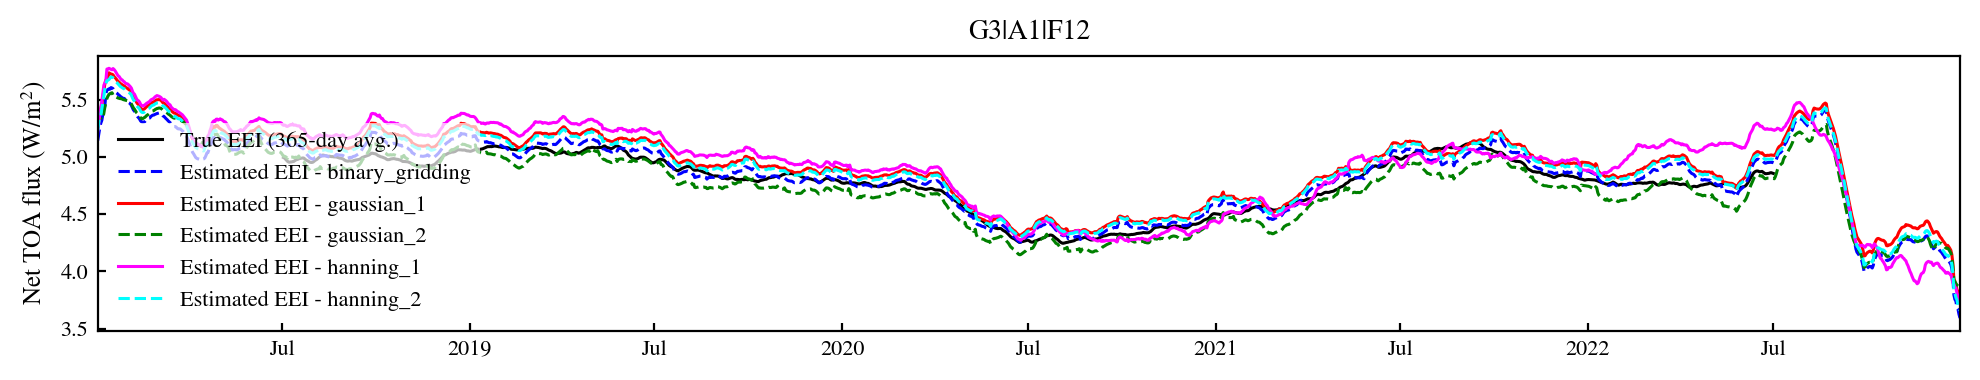

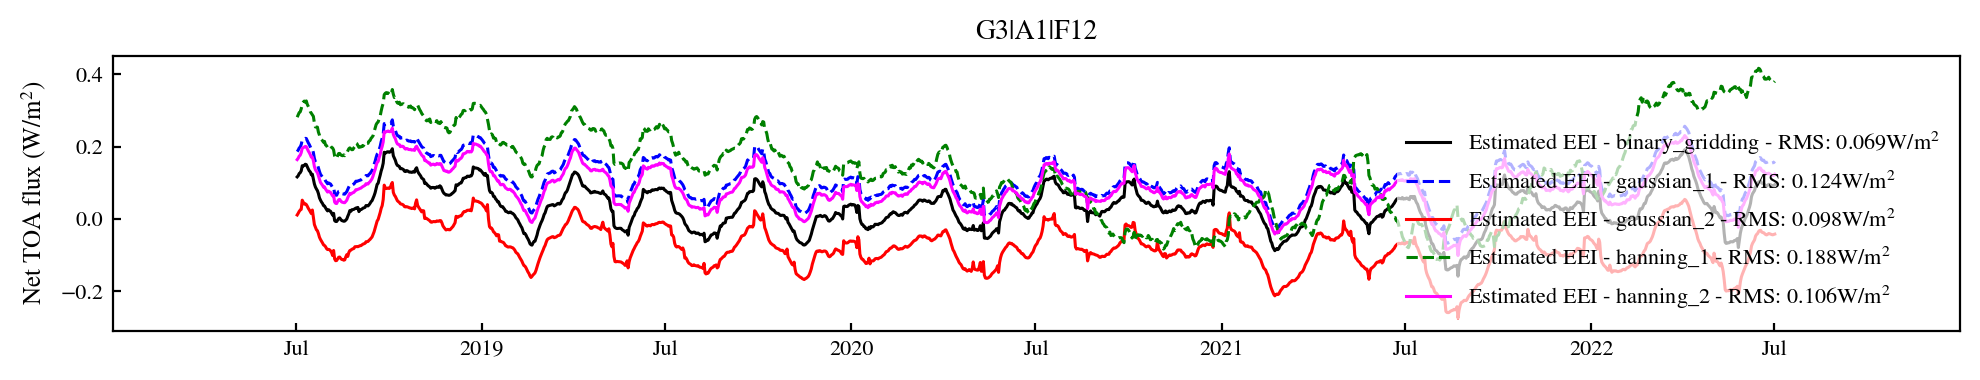

In [17]:
# testing smoothing methods:

orbits = ['G3', 'A1', 'F12'] 
EEI_name = "EEI_truth_1" # check_EEI_consistency(SB_constellation)
window_days = 365
stacking_grid = QuadratureGrid(alt_km=800, order=131)
frame='SFF'
accelerometer_dict=dict()
methods=['binary_gridding', 'gaussian_1', 'gaussian_2', 'hanning_1', 'hanning_2']

EEI_truth_smooth = get_EEI_smooth_true(EEI_name, window_days)
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
SB_constellation = np.concatenate([input_manager.get_primary_keys({'orbit_name': orb,
                                                    'force_settings': 2,
                                                    'integration_settings': 0,
                                                    'delta_t_out': 15,
                                                    'SC_name': 'SC_0'
                                                    }) for orb in orbits])
orbits_str = '|'.join([input_manager.get_dicts(sb)['orbit']['orbit_name'] for sb in SB_constellation])
dict_to_plot = {'True EEI ('+str(window_days)+'-day avg.)': EEI_truth_smooth}

for method in methods:
    estimated_EEI = compute_EEI_estimated_time_series(SB_constellation, window_days, stacking_grid, frame, 
                                                    method, EEI_name, accelerometer_dict)
    dict_to_plot['Estimated EEI - '+method] = estimated_EEI

plot_estimation(dict_to_plot, mid_day_jd_array, orbits_str)

errors_dict = {}
for i, (label, estimated) in enumerate(dict_to_plot.items()):
    if i>0:
        error = estimated - EEI_truth_smooth
        rms = nanrms(error)
        errors_dict[label + ' - RMS: ' + f"{rms:.3f}" + 'W/m$^2$'] = error

plot_estimation(errors_dict, mid_day_jd_array, orbits_str)

In [ ]:
# single run

orbits = ['G3', 'A1', 'F12'] 
EEI_name = "EEI_truth_0" # check_EEI_consistency(SB_constellation)
window_days = 365
stacking_grid = QuadratureGrid(alt_km=800, order=131)
frame='SFF'
method='binary_gridding'
accelerometer_dict = {}

EEI_truth_smooth = get_EEI_smooth_true(EEI_name, window_days)
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
SB_constellation = np.concatenate([input_manager.get_primary_keys({'orbit_name': orb,
                                                    'force_settings': 2,
                                                    'integration_settings': 0,
                                                    'delta_t_out': 15,
                                                    }) for orb in orbits])
orbits_str = '|'.join([input_manager.get_dicts(sb)['orbit']['orbit_name'] for sb in SB_constellation])

estimated_EEI = compute_EEI_estimated_time_series(SB_constellation, window_days, stacking_grid, frame, 
                                                  method, EEI_name, accelerometer_dict)

dict_to_plot = {'True EEI ('+str(window_days)+'-day avg.)': EEI_truth_smooth,
                'Estimated EEI ('+str(window_days)+'-day avg.)': estimated_EEI}
plot_estimation(dict_to_plot, mid_day_jd_array, orbits_str)

rms = nanrms(estimated_EEI - EEI_truth_smooth)
error_title = orbits_str + ' - error RMS: ' + f"{rms:.5f} W/m$^2$"
errors_dict = {}
errors_dict['Estimated EEI ('+str(window_days)+'-day avg.)'] = estimated_EEI - EEI_truth_smooth
plot_estimation(errors_dict, mid_day_jd_array, error_title)

Old blocks below:

In [ ]:
import numpy as np
import sys, os
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, estimate_EEI_avg, get_window_avg_maps, check_EEI_consistency, get_all_jd_windows #, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms
from SpaceBalls.sph_meshing import Grid
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.plotter import Plotter
import config.constants as constants
RE = constants.earth_radius()
import itertools
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
%matplotlib inline

def make_EEI_estimate_plots(SB_constellation, window_days, window_name, grid: Grid, frame, EEI_smooth_true_coarse, mid_day_jd_array, full_jd_array, EEI_true, method):

    EEI_name = "EEI_truth_0" # check_EEI_consistency(SB_constellation)
    orbits_str = '|'.join([input_manager.get_dicts(sb)['orbit']['orbit_name'] for sb in SB_constellation])
    print(f"Running EEI estimatie for constellation {orbits_str}...")

    #for window_name, window_days in zip(smoothing_windows_names, smoothing_windows_days):
    print(f"Running smooth estimate {window_days}-day window")
    rad_config = radiation_settings_from_EEI_truth_name(EEI_name)
    jd_0 = rad_config["jd_interval"][0]
    jd_windows = get_all_jd_windows(EEI_name, window_days)
    #first_block = [[jd_0, jd_0 + (i+1)] for i in range(int(np.squeeze(np.diff(jd_windows[0])-1)))]
    #jd_windows = np.vstack((first_block, jd_windows))
    #jd_vec = np.array([win[-1] for win in jd_windows])

    
    EEI_smooth_estimated, estimated_maps = estimate_EEI_avg(
                                    sb_names=SB_constellation, 
                                    jd_windows=jd_windows, 
                                    grid=grid, method=method, frame=frame,
                                    meas_mode='recomp_radial',
                                    return_avg_flux_maps=True) # 'gaussian_1.5'
    
    EEI_smooth_estimated_noise = estimate_EEI_avg(
                                    sb_names=SB_constellation, 
                                    jd_windows=jd_windows, 
                                    grid=grid, method=method, frame=frame,
                                    meas_mode='recomp_radial',
                                    return_avg_flux_maps=False,
                                    #add_noise=True 
                                    accelerometer_dict={'noise_asd': 'grattis',
                                                        'biases': np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]]), # rows: sats; cols: RIC
                                                        'scale_matrices': [np.array([[0.95, 0, 0], 
                                                                                     [0, 1.05, 0], 
                                                                                     [0, 0, 1]]) for _ in range(3)],
                                                        'subsample_dt': None,
                                                        'rotation_revs_per_T': [10, 10, 10],
                                                        'rotation_axes_RIC': np.array([[0,0,1], [0,0,1], [0,0,1]])
                                                         }
                                    )
    
    """
    initial_n_days = int(np.squeeze(np.diff(jd_windows[0])))
    first_block_jd = np.arange(jd_windows[0][0], jd_windows[0][1])

    mid_day_jd_array_sat = mid_day_jd_array - initial_n_days
    last_frag = np.arange(mid_day_jd_array_sat[-1], mid_day_jd_array[-1], 1)
    mid_day_jd_array_sat = np.concatenate((mid_day_jd_array_sat, last_frag))
    EEI_smooth_estimated = np.concatenate((np.full(initial_n_days, np.nan), EEI_smooth_estimated))
    EEI_smooth_true_coarse = np.concatenate((np.full(initial_n_days, np.nan), EEI_smooth_true_coarse))
    
    frame_tag = '_SFF_accurate' if frame=="SFF" else ''
    #true_avg_flux_maps = get_window_avg_maps("EEI_truth_1", jd_windows, 'daily_avg_net_Fr_800km'+frame_tag, grid)
    #error_maps = np.asarray(estimated_maps) - np.asarray(true_avg_flux_maps)
    #integrated_error_maps = grid.compute_surf_integral(error_maps.T) / (4*np.pi*RE**2)
    
    Plotter.plot_animated_time_series(mid_day_jd_array_sat,
                        {'Estimated EEI('+window_name+' avg.)': EEI_smooth_estimated,
                        'True EEI ('+window_name+' avg.)': EEI_smooth_true_coarse,
                        },
                        f_width=2.5, f_height=0.5,
                        ylabel='Net TOA flux (W/m$^2$)',
                        #y_scatter_dict={'$phi(t)$ (W/m$^2$)': (full_jd_array, EEI_true)},
                        #scatter_alpha=0.007,
                        title='Constellation '+ orbits_str,
                        ylim=[np.nanmin(np.concatenate((EEI_smooth_true_coarse, EEI_smooth_estimated)))-0.1,
                              np.nanmax(np.concatenate((EEI_smooth_true_coarse, EEI_smooth_estimated)))+0.1],
                        file_name='test_curve_animation_2',
                        animated_keys=['Estimated EEI('+window_name+' avg.)'],
                        add_moving_vline=True,
                        moving_vline_jd_array=np.concatenate((mid_day_jd_array, mid_day_jd_array[-1] * np.ones(initial_n_days+1))),
                        add_avg_window=True,
                        window_days=365
                        )
    """
    
    Plotter.plot_time_series(mid_day_jd_array,
                        {'Estimated EEI ('+window_name+' avg.)': EEI_smooth_estimated,
                         'True EEI ('+window_name+' avg.)': EEI_smooth_true_coarse,
                         'Estimated EEI ('+window_name+' avg.) with noise': EEI_smooth_estimated_noise
                         },
                        f_width=2.5, f_height=0.5,
                        ylabel='Net TOA flux (W/m$^2$)',
                        y_scatter_dict={'$phi(t)$ (W/m$^2$)': (full_jd_array, EEI_true)},
                        scatter_alpha=0.007,
                        title='Constellation '+ orbits_str,
                        ylim=[np.nanmin(np.concatenate((EEI_smooth_true_coarse, EEI_smooth_estimated)))-0.1,
                              np.nanmax(np.concatenate((EEI_smooth_true_coarse, EEI_smooth_estimated)))+0.1]
                        )

    
    error = EEI_smooth_estimated-EEI_smooth_true_coarse
    rms = nanrms(error)

    error_with_noise = EEI_smooth_estimated_noise - EEI_smooth_true_coarse
    rms_noise = nanrms(error_with_noise)

    #rms_error_map = nanrms(error_maps, axis=0)
    #rms2 = grid.compute_surf_integral(rms_error_map) / (4*np.pi*RE**2)
    #print(f"RMS: {rms}")
    #print(f"RMS2: {rms2}")

    Plotter.plot_time_series(mid_day_jd_array,
                        {'Estimation error': error,
                         'Estimation error with noise': error_with_noise
                         #'Estimation error from maps': integrated_error_maps,
                         },
                        f_width=2.5, f_height=0.5,
                        ylabel='Error (W/m$^2$)',
                        title=f"Error RMS: {rms} / {rms_noise}",
                        zero_hline=True)
    

def make_EEI_estimate_plots_smooth_test(SB_constellation, window_days, window_name, grid, EEI_smooth_true_coarse, mid_day_jd_array, full_jd_array, EEI_true,
                                        smooth_method="hanning"):

    orbits_str = '|'.join([input_manager.get_dicts(sb)['orbit']['orbit_name'] for sb in SB_constellation])
    print(f"Running EEI estimatie for constellation {orbits_str}...")

    #for window_name, window_days in zip(smoothing_windows_names, smoothing_windows_days):
    print(f"Running smooth estimate {window_days}-day window")

    jd_windows = np.zeros((len(mid_day_jd_array), 2))
    for i, mid_day_jd in enumerate(mid_day_jd_array):
        jd_windows[i,:] = [
            max(mid_day_jd - window_days/2, mid_day_jd_array[0]  - 0.5),
            min(mid_day_jd + window_days/2, mid_day_jd_array[-1] + 0.5),
        ]

    kernel_widths = [1.5, 2.5, 4, 6, 9]
    EEI_smooth_estimated_array = [None] * len(kernel_widths)

    for i, width in enumerate(kernel_widths):
        EEI_smooth_estimated_array[i] = estimate_EEI_avg(sb_names=SB_constellation, 
                                        jd_windows=jd_windows, 
                                        grid=grid, method=smooth_method+'_'+str(width), frame="SFF",
                                        meas_mode='recomp_radial') # 'gaussian_1.5'
    dict_to_plot = {}
    dict_to_plot['True EEI ('+window_name+' avg.)'] = EEI_smooth_true_coarse
    for (deg, est_array) in zip(kernel_widths, EEI_smooth_estimated_array):
        dict_to_plot['Estimated EEI (Gaussian '+str(deg)+'deg)'] = est_array

        
    Plotter.plot_time_series(mid_day_jd_array,
                        dict_to_plot,
                        f_width=2.5, f_height=0.5,
                        ylabel='Net TOA flux (W/m$^2$)',
                        y_scatter_dict={'$phi(t)$ (W/m$^2$)': (full_jd_array, EEI_true)},
                        scatter_alpha=0.007,
                        title='Constellation '+ orbits_str,
                        ylim=[np.nanmin(np.concatenate((EEI_smooth_true_coarse, np.concatenate(EEI_smooth_estimated_array))))-0.1,
                              np.nanmax(np.concatenate((EEI_smooth_true_coarse, np.concatenate(EEI_smooth_estimated_array))))+0.1]
                        )
    
    #error = EEI_smooth_estimated-EEI_smooth_true_coarse
    dict_to_plot_err = {'Error (Gaussian '+str(deg)+'deg)': est_array-EEI_smooth_true_coarse
                         for (deg, est_array) in zip(kernel_widths, EEI_smooth_estimated_array)}
    
    Plotter.plot_time_series(mid_day_jd_array,
                        dict_to_plot_err,
                        f_width=2.5, f_height=0.5,
                        ylabel='Error (W/m$^2$)',
                        #title=f"Error RMS: {nanrms(error)}"
                        )


In [ ]:
from SpaceBalls.sph_meshing import QuadratureGrid, RegularLatLonGrid

EEI_name = "EEI_truth_0"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
EEI_true_time_series = get_true_EEI_time_series(EEI_name)

window_days = 365
window_name = str(window_days)+'-day'
EEI_smooth_true = normal_smoother(EEI_true_time_series, full_jd_array, window_width_days=window_days, 
                                out_length_mode='same_with_nans')
EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)

all_primary_keys = input_manager.get_primary_keys(filters={'force_settings': 2,
                                                           'integration_settings': 0},
                                                  table_name='sb_table',
                                                  pk_column='sb_hash')
completed_bool_array = [os.path.exists(os.path.join(OUTPUT_DIR, key, 'day_1825', 'erp.npy')) for key in all_primary_keys]

all_primary_keys = [key for key in all_primary_keys if 'LAGEOS' not in key]
combinations = list(itertools.combinations((all_primary_keys), 8))
sample_combinations = random.sample(combinations, 1)

frame="SFF"

grid_quad_2 = QuadratureGrid(alt_km=800, order=225)
grid_quad = QuadratureGrid(alt_km=800, order=131)

reg_deg_bin_size = 1
grid_reg = RegularLatLonGrid(alt_km=800, n_lat=int(180/reg_deg_bin_size), n_lon=int(360/reg_deg_bin_size))

['c1dd568b730da76c', '7b54acc8701b0625','82c0c7e77260bb76']

for SB_constellation in sample_combinations:

    #SB_constellation = ['32c08b39a7c5dce2', '7b54acc8701b0625', '82c0c7e77260bb76'] # best 3-sat, 1-yr
    #SB_constellation = ['c1dd568b730da76c', '7b54acc8701b0625','82c0c7e77260bb76']

    #SB_constellation = ['7b54acc8701b0625','82c0c7e77260bb76','c1dd568b730da76c']
    #inclinations = [input_manager.get_dicts(sb)["orbit"]["i_0"] for sb in SB_constellation]
    #names = [input_manager.get_dicts(sb)["orbit"]["orbit_name"] for sb in SB_constellation]
    #print(f"Inlcinations: {inclinations}")

    #SB_constellation = ['9e750b3b250f449b', 'bc67760fbec64597'] # best 2-sat, 1-yr
    
    #orbits = ['A3', 'E1', 'E3']
    orbits = ['G3', 'A1', 'F12'] # ['C1', 'I3', 'F2']
    #orbits = ['R800_24', 'R800_32', 'R800_7']
    SB_constellation = np.concatenate([input_manager.get_primary_keys({'orbit_name': orb,
                                                        'force_settings': 2,
                                                        'integration_settings': 0,
                                                        'delta_t_out': 15,
                                                        }) for orb in orbits])

    make_EEI_estimate_plots(SB_constellation, window_days, window_name, grid_quad, frame, EEI_smooth_true_coarse, 
                            mid_day_jd_array, full_jd_array, EEI_true_time_series, 
                            method='binary_gridding')
    
    # NEXT: comprovar integral de SFF_accurate vs TOA vs ECEF 800km (plotting_EEI notebook)
    
    #make_EEI_estimate_plots(SB_constellation, window_days, window_name, grid_quad, EEI_smooth_true_coarse, 
    #                        mid_day_jd_array, full_jd_array, EEI_true_time_series)
    #
    #make_EEI_estimate_plots(SB_constellation, window_days, window_name, grid_reg, EEI_smooth_true_coarse, 
    #                        mid_day_jd_array, full_jd_array, EEI_true_time_series)

In [4]:
# on-the go test of new MONTE meshing

from SpaceBalls.sph_meshing import QuadratureGrid, RegularLatLonGrid
import numpy as np
import sys, os
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, estimate_EEI_avg #, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.plotter import Plotter

EEI_name = "EEI_truth_1"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
EEI_true_time_series = get_true_EEI_time_series(EEI_name)

window_days = 365
window_name = str(window_days)+'-day'
EEI_smooth_true = normal_smoother(EEI_true_time_series, full_jd_array, window_width_days=window_days, 
                                out_length_mode='same_with_nans')
EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)

orbits = ['G3', 'I2', 'E2']
SB_constellation_og_monte = np.concatenate([input_manager.get_primary_keys({'orbit_name': orb,
                                                    'force_settings': 2,
                                                    'integration_settings': 0,
                                                    'delta_t_out': 15,
                                                    'sc_name': 'SC_0',
                                                    }) for orb in orbits])
SB_constellation_new_monte = np.concatenate([input_manager.get_primary_keys({'orbit_name': orb,
                                                    'force_settings': 2,
                                                    'integration_settings': 115,
                                                    'delta_t_out': 15,
                                                    'sc_name': 'SC_0',
                                                    }) for orb in orbits])


#SB_constellation_og_monte = ['ff616870cd0c6bdf', 'a740b257b98409b4', '2151699c6e13c489']
#SB_constellation_new_monte = ['d65091f9f07b0c30', '660be781ad2b3217', 'b1f6ca094d91aac1']

orbits_str = '|'.join([input_manager.get_dicts(sb)['orbit']['orbit_name'] for sb in SB_constellation_og_monte])
print(f"Running EEI estimatie for constellation {orbits_str}...")

#for window_name, window_days in zip(smoothing_windows_names, smoothing_windows_days):
print(f"Running smooth estimate {window_days}-day window")

jd_windows = np.zeros((len(mid_day_jd_array), 2))
for i, mid_day_jd in enumerate(mid_day_jd_array):
    jd_windows[i,:] = [
        max(mid_day_jd - window_days/2, mid_day_jd_array[0]  - 0.5),
        min(mid_day_jd + window_days/2, mid_day_jd_array[-1] + 0.5),
    ]

grid = QuadratureGrid(alt_km=800, order=131)
EEI_smooth_estimated_new_monte = estimate_EEI_avg(sb_names=SB_constellation_new_monte, 
                                jd_windows=jd_windows, 
                                grid=grid, method='binary_gridding', frame="SFF",
                                meas_mode='monte')
#EEI_smooth_estimated_new_monte[int(350-365/2):] = np.nan

EEI_smooth_estimated_recomp = estimate_EEI_avg(sb_names=SB_constellation_og_monte, 
                                jd_windows=jd_windows, 
                                grid=grid, method='binary_gridding', frame="SFF",
                                meas_mode='recomp_radial') 
EEI_smooth_estimated_og_monte = estimate_EEI_avg(sb_names=SB_constellation_og_monte, 
                                jd_windows=jd_windows, 
                                grid=grid, method='binary_gridding', frame="SFF",
                                meas_mode='monte') # 'gaussian_1.5'


        

Running EEI estimatie for constellation G3|I2|E2...
Running smooth estimate 365-day window
Computing batch 0
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output variable: jd_vec
Getting output variable: jd_vec
Loading daily jd_vec files...
[████████████████████████████████████████] 100.00%
Getting output variable: jd_vec
Entering get_global_meas_idxs for var jd_vec
Getting output variable: jd_vec
Getting r_hist_array...
Getting output variable: xyz_sun_frame
Entering get_global_meas_idxs for var xyz_sun_frame
Getting output variable: jd_vec
Getting output variable: xyz_sun_frame
Loading daily xyz_sun_frame files...
[████████████████████████████████████████] 100.00%
Getting output variable: xyz_sun_frame
Entering get_global_meas_idxs for var xyz_sun_frame
Getting output variable: jd_vec
Getting output variable: srp
Entering get_global_meas_idxs for var srp
Getting output variable: jd_vec
Getting output variable: srp
Loading daily srp files...
[███

(<Figure size 2000x400 with 1 Axes>,
 <Axes: title={'center': 'Constellation G3|I2|E2'}, ylabel='Net TOA flux (W/m$^2$)'>)

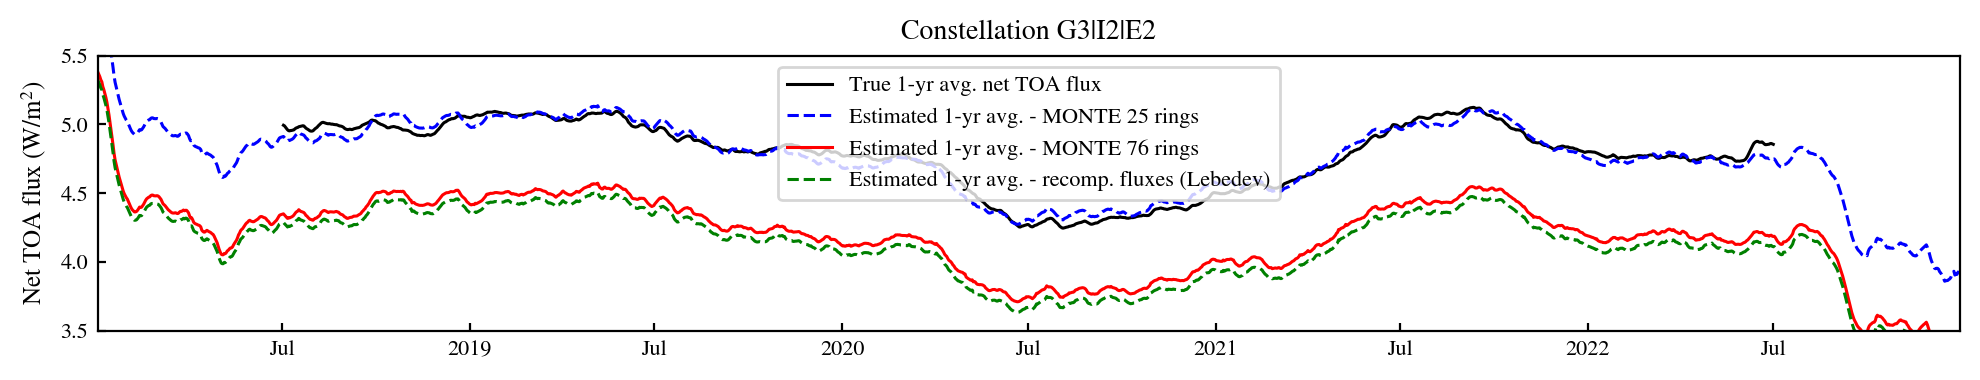

In [9]:

Plotter.plot_time_series(mid_day_jd_array,
                    {'True 1-yr avg. net TOA flux': EEI_smooth_true_coarse,
                     'Estimated 1-yr avg. - MONTE 25 rings': EEI_smooth_estimated_og_monte,
                     'Estimated 1-yr avg. - MONTE 76 rings': EEI_smooth_estimated_new_monte,
                     'Estimated 1-yr avg. - recomp. fluxes (Lebedev)': EEI_smooth_estimated_recomp,
                     },
                    f_width=2.5, f_height=0.5,
                    ylabel='Net TOA flux (W/m$^2$)',
                    #y_scatter_dict={'True instantaneous net TOA flux': (full_jd_array, EEI_true_time_series)},
                    scatter_alpha=0.007,
                    title='Constellation '+ orbits_str,
                    ylim=[3.5, 5.5]
                    )

In [ ]:
from SpaceBalls.postproc_EEI_estimation import generate_constellation_day_animations, generate_constellation_stacking_animations

import sys, os
import numpy as np
import SpaceBalls.output_database_manager as db_manager
from SpaceBalls.plotter import Plotter
from SpaceBalls.postproc_EEI_estimation import generate_constellation_stacking_animations, generate_error_map_animations
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, check_EEI_consistency, get_all_jd_windows
from SpaceBalls.utils import normal_smoother
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR
from SpaceBalls.sph_meshing import QuadratureGrid

# quik run of single animation

# 7c826965b6b89923 - 7b54acc8701b0625|82c0c7e77260bb76|c1dd568b730da76c - c1dd.. is C1
# 0d6ab748882d60fa - 32c08b39a7c5dce2|7b54acc8701b0625|82c0c7e77260bb76 - 32c08.. is A1

key = '7c826965b6b89923'
sb_names = ['7b54acc8701b0625','82c0c7e77260bb76','c1dd568b730da76c']
window_days = 365
EEI_name = check_EEI_consistency(sb_names)
jd_windows = get_all_jd_windows(EEI_name, window_days)
grid = QuadratureGrid(alt_km=800, order=131)

#generate_error_map_animations(sb_names, key, jd_windows, grid)
generate_constellation_stacking_animations(sb_names, key, jd_windows, grid)


In [ ]:
idx_0 = np.where(~np.isnan(EEI_smooth_true_coarse))[0][0]
EEI_smooth_estimated[idx_0]

error = EEI_smooth_estimated-EEI_smooth_true_coarse
from SpaceBalls.utils import nanrms
nanrms(error)

In [ ]:
import numpy as np
import sys, os
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, estimate_EEI_avg, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.plotter import Plotter
import config.constants as constants
import itertools
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
%matplotlib inline

EEI_name = "EEI_truth_1"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
EEI_true_time_series = get_true_EEI_time_series(EEI_name, 720, 360)

window_days = 365
window_name = '1-year'
EEI_smooth_true = normal_smoother(EEI_true_time_series, full_jd_array, window_width_days=window_days, 
                                out_length_mode='same_with_nans')
EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)


all_primary_keys = input_manager.get_primary_keys(filters={'force_settings': 3},
                                                  table_name='sb_table',
                                                  pk_column='sb_hash')
completed_bool_array = [os.path.exists(os.path.join(OUTPUT_DIR, key, 'day_1825', 'erp.npy')) for key in all_primary_keys]

all_primary_keys = [key for (key, comp) in zip(all_primary_keys, completed_bool_array) if comp]

orbits = [input_manager.get_dicts(sb)['orbit']['orbit_name'] for i, sb in enumerate(all_primary_keys)]
print(orbits)

combinations = list(itertools.combinations((all_primary_keys), 3))
sample_combinations = random.sample(combinations, 3)

for SB_constellation in sample_combinations:

    # find constellation with old settings:
    orbit_names = [input_manager.get_dicts(sb)['orbit']['orbit_name'] for sb in SB_constellation]
    old_keys = [input_manager.get_primary_keys(filters={'force_settings': 2,
                                                        'orbit_name': orb},
                                                  table_name='sb_table',
                                                  pk_column='sb_hash')[0] for orb in orbit_names]
    make_EEI_estimate_plots(old_keys, window_days, window_name, EEI_smooth_true_coarse, 
                            mid_day_jd_array, full_jd_array, EEI_true_time_series)
    
    make_EEI_estimate_plots(SB_constellation, window_days, window_name, EEI_smooth_true_coarse, 
                            mid_day_jd_array, full_jd_array, EEI_true_time_series)
    
    # equivalent in 



In [ ]:
import numpy as np
import sys, os
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, estimate_EEI_avg, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.plotter import Plotter
import config.constants as constants
import itertools
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
%matplotlib inline

EEI_name = "EEI_truth_1"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
EEI_true_time_series = get_true_EEI_time_series(EEI_name, 720, 360)

window_days = 365
window_name = '1-year'
EEI_smooth_true = normal_smoother(EEI_true_time_series, full_jd_array, window_width_days=window_days, 
                                out_length_mode='same_with_nans')
EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)


all_primary_keys = input_manager.get_primary_keys(filters={'force_settings': 3},
                                                  table_name='sb_table',
                                                  pk_column='sb_hash')
completed_bool_array = [os.path.exists(os.path.join(OUTPUT_DIR, key, 'day_1825', 'erp.npy')) for key in all_primary_keys]

all_primary_keys = [key for (key, comp) in zip(all_primary_keys, completed_bool_array) if comp]

orbits = [input_manager.get_dicts(sb)['orbit']['orbit_name'] for i, sb in enumerate(all_primary_keys)]
print(orbits)

combinations = list(itertools.combinations((all_primary_keys), 3))
sample_combinations = random.sample(combinations, 3)

for SB_constellation in sample_combinations:

    # find constellation with old settings:
    orbit_names = [input_manager.get_dicts(sb)['orbit']['orbit_name'] for sb in SB_constellation]
    old_keys = [input_manager.get_primary_keys(filters={'force_settings': 2,
                                                        'orbit_name': orb},
                                                  table_name='sb_table',
                                                  pk_column='sb_hash')[0] for orb in orbit_names]
    
    for sb_old, sb_new in zip(SB_constellation, old_keys):
        full_srp_time_series_old = np.load(os.path.join(OUTPUT_DIR, sb_old, 'concatenated_srp.npy'))
        full_srp_time_series_new = np.load(os.path.join(OUTPUT_DIR, sb_new, 'concatenated_srp.npy'))
        diff = full_srp_time_series_old - full_srp_time_series_new
        print(np.max(np.abs(diff)))
